# ME1: Manual Three-Layer CNN for MNIST

This notebook implements and trains a compact CNN without `nn.Conv2d`, `nn.Linear`, or built-in activation/pooling modules. Convolution and classification use explicit learnable parameters and tensor contractions.

## 1. Setup and Data

The standard MNIST train/test splits are stored under `data/`. Seeds make initialization, loading, and visualization reproducible where practical; CUDA is limited externally to one visible device.

In [1]:
import math
import random
from pathlib import Path

import matplotlib.pyplot as plt
import torch
from einops import rearrange, reduce
from torch import nn
from torch.utils.data import DataLoader
from torchvision import datasets, transforms

SEED = 42
BATCH_SIZE = 256
EPOCHS = 5
LEARNING_RATE = 3e-3

random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
    torch.backends.cudnn.benchmark = False
    torch.backends.cudnn.deterministic = True

device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print(f"PyTorch: {torch.__version__}")
print(f"Device: {device}" + (f" ({torch.cuda.get_device_name(0)})" if device.type == "cuda" else ""))


PyTorch: 2.13.0+cu130
Device: cuda:0 (NVIDIA A100-SXM4-40GB)


In [2]:
data_directory = Path("data")
image_transform = transforms.ToTensor()

train_dataset = datasets.MNIST(
    root=data_directory, train=True, download=True, transform=image_transform
)
test_dataset = datasets.MNIST(
    root=data_directory, train=False, download=True, transform=image_transform
)

loader_generator = torch.Generator().manual_seed(SEED)
train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=2,
    pin_memory=device.type == "cuda",
    persistent_workers=True,
    generator=loader_generator,
)
test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=device.type == "cuda",
    persistent_workers=True,
)
print(f"Training examples: {len(train_dataset):,}; test examples: {len(test_dataset):,}")


Training examples: 60,000; test examples: 10,000


## 2. Custom CNN Model

`ManualConv2d` pads a `B×C×H×W` tensor, creates sliding kernel views with `Tensor.unfold`, and uses `einops` to name/rearrange patch axes. `torch.einsum` contracts each patch with an `O×C×K×K` weight tensor. ReLU is `torch.clamp(min=0)`. Downsampling rearranges each non-overlapping 2×2 window and takes its maximum with `einops.reduce`; the final feature map is rearranged from `B×48×7×7` to `B×2352`. The classifier contracts these features with a learnable `10×2352` matrix using `einsum`. All weights and biases are `nn.Parameter` instances.

In [3]:
class ManualConv2d(nn.Module):
    """Same-padded 2D cross-correlation using tensor views and einsum."""

    def __init__(
        self,
        input_channels: int,
        output_channels: int,
        kernel_size: int = 3,
    ) -> None:
        super().__init__()
        if kernel_size % 2 == 0:
            raise ValueError("kernel_size must be odd for symmetric padding")

        self.kernel_size = kernel_size
        self.padding = kernel_size // 2
        weight_scale = math.sqrt(2.0 / (input_channels * kernel_size**2))
        self.weight = nn.Parameter(
            torch.randn(output_channels, input_channels, kernel_size, kernel_size)
            * weight_scale
        )
        self.bias = nn.Parameter(torch.zeros(output_channels))

    def forward(self, inputs: torch.Tensor) -> torch.Tensor:
        padded_inputs = torch.nn.functional.pad(
            inputs, (self.padding, self.padding, self.padding, self.padding)
        )
        patches = padded_inputs.unfold(2, self.kernel_size, 1).unfold(
            3, self.kernel_size, 1
        )
        patches = rearrange(patches, "b c h w kh kw -> b h w c kh kw")
        outputs = torch.einsum("bhwcij,ocij->bohw", patches, self.weight)
        return outputs + self.bias[None, :, None, None]


def relu(inputs: torch.Tensor) -> torch.Tensor:
    """Elementwise ReLU expressed directly as a tensor operation."""
    return torch.clamp(inputs, min=0.0)


def max_pool_2x2(inputs: torch.Tensor) -> torch.Tensor:
    """Non-overlapping 2x2 max pooling with explicit block rearrangement."""
    blocks = rearrange(inputs, "b c (h ph) (w pw) -> b c h w ph pw", ph=2, pw=2)
    return reduce(blocks, "b c h w ph pw -> b c h w", "max")


class ManualMnistCnn(nn.Module):
    """Exactly three manual convolutions followed by a manual classifier."""

    def __init__(self) -> None:
        super().__init__()
        self.conv1 = ManualConv2d(1, 16)
        self.conv2 = ManualConv2d(16, 32)
        self.conv3 = ManualConv2d(32, 48)
        classifier_input_size = 48 * 7 * 7
        classifier_scale = math.sqrt(2.0 / classifier_input_size)
        self.classifier_weight = nn.Parameter(
            torch.randn(10, classifier_input_size) * classifier_scale
        )
        self.classifier_bias = nn.Parameter(torch.zeros(10))

    def forward(self, images: torch.Tensor) -> torch.Tensor:
        features = relu(self.conv1(images))                 # B x 16 x 28 x 28
        features = max_pool_2x2(relu(self.conv2(features))) # B x 32 x 14 x 14
        features = max_pool_2x2(relu(self.conv3(features))) # B x 48 x 7 x 7
        features = rearrange(features, "b c h w -> b (c h w)")
        return torch.einsum("bf,of->bo", features, self.classifier_weight) + self.classifier_bias


model = ManualMnistCnn().to(device)
parameter_count = sum(parameter.numel() for parameter in model.parameters())
print(model)
print(f"Learnable parameters: {parameter_count:,}")


ManualMnistCnn(
  (conv1): ManualConv2d()
  (conv2): ManualConv2d()
  (conv3): ManualConv2d()
)
Learnable parameters: 42,202


## 3. Training and Evaluation

Cross-entropy and AdamW are standard allowed utilities. The following loop performs exactly five complete training epochs and reports loss, training accuracy, and official test-split accuracy after each epoch. A pre-training backward check confirms every custom parameter receives a finite gradient.

In [4]:
sample_images, sample_labels = next(iter(train_loader))
sample_logits = model(sample_images[:8].to(device))
sample_loss = torch.nn.functional.cross_entropy(sample_logits, sample_labels[:8].to(device))
sample_loss.backward()
assert all(
    parameter.grad is not None and torch.isfinite(parameter.grad).all()
    for parameter in model.parameters()
), "Every learnable parameter must receive a finite gradient"
model.zero_grad(set_to_none=True)
print(f"Gradient check passed for all {len(list(model.parameters()))} parameter tensors.")


Gradient check passed for all 8 parameter tensors.


In [5]:
optimizer = torch.optim.AdamW(
    model.parameters(), lr=LEARNING_RATE, weight_decay=1e-4
)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)
epoch_metrics = []

for epoch in range(1, EPOCHS + 1):
    model.train()
    training_loss_sum = 0.0
    training_correct = 0

    for images, labels in train_loader:
        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)
        optimizer.zero_grad(set_to_none=True)
        logits = model(images)
        loss = torch.nn.functional.cross_entropy(logits, labels)
        loss.backward()
        optimizer.step()

        training_loss_sum += loss.item() * labels.size(0)
        training_correct += (logits.argmax(dim=1) == labels).sum().item()

    model.eval()
    test_correct = 0
    with torch.inference_mode():
        for images, labels in test_loader:
            images = images.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True)
            predicted_labels = model(images).argmax(dim=1)
            test_correct += (predicted_labels == labels).sum().item()

    training_loss = training_loss_sum / len(train_dataset)
    training_accuracy = 100.0 * training_correct / len(train_dataset)
    test_accuracy = 100.0 * test_correct / len(test_dataset)
    epoch_metrics.append((epoch, training_loss, training_accuracy, test_accuracy))
    print(
        f"Epoch {epoch}/{EPOCHS} | loss: {training_loss:.4f} | "
        f"train accuracy: {training_accuracy:.2f}% | test accuracy: {test_accuracy:.2f}%"
    )
    scheduler.step()

final_test_accuracy = epoch_metrics[-1][3]
print(f"\nFinal MNIST test accuracy: {final_test_accuracy:.2f}%")


Epoch 1/5 | loss: 0.2171 | train accuracy: 93.87% | test accuracy: 98.46%


Epoch 2/5 | loss: 0.0455 | train accuracy: 98.58% | test accuracy: 98.74%


Epoch 3/5 | loss: 0.0286 | train accuracy: 99.11% | test accuracy: 99.07%


Epoch 4/5 | loss: 0.0173 | train accuracy: 99.45% | test accuracy: 99.09%


Epoch 5/5 | loss: 0.0110 | train accuracy: 99.70% | test accuracy: 99.18%

Final MNIST test accuracy: 99.18%


## 4. Predictions and Results

Sixteen deterministic random samples from the official test split are inferred in one batch. Each title shows the required ground truth and prediction.

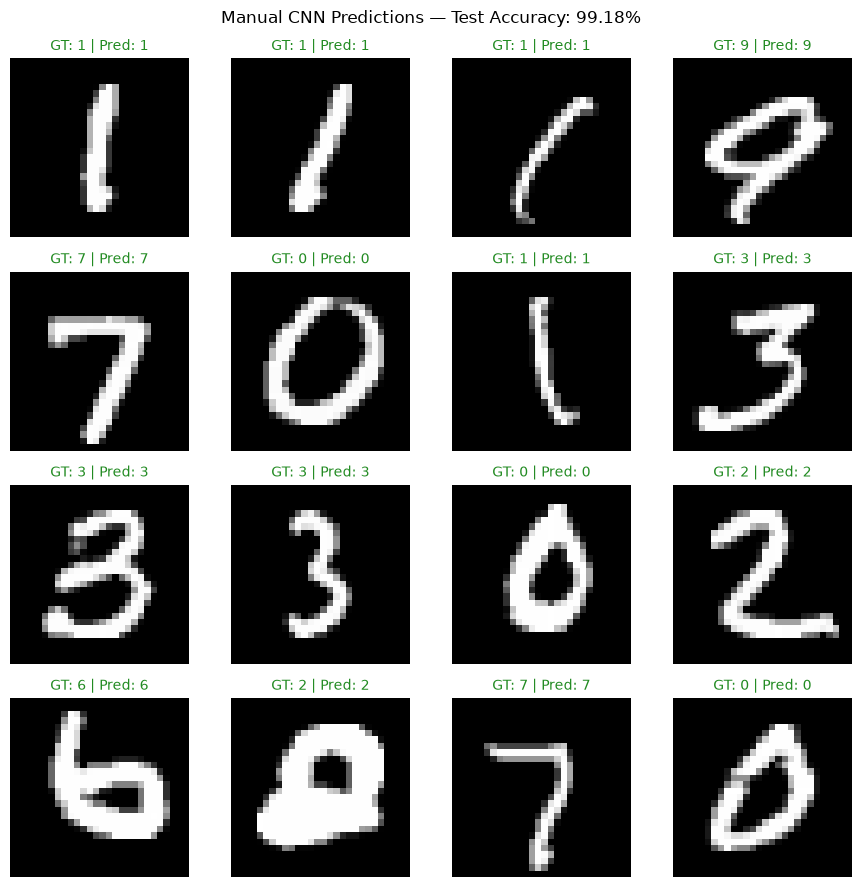

In [6]:
visualization_generator = torch.Generator().manual_seed(SEED + 1)
sample_indices = torch.randperm(
    len(test_dataset), generator=visualization_generator
)[:16]
visualization_images = torch.stack([test_dataset[index][0] for index in sample_indices])
ground_truth_labels = torch.tensor([test_dataset[index][1] for index in sample_indices])

model.eval()
with torch.inference_mode():
    predicted_labels = model(visualization_images.to(device)).argmax(dim=1).cpu()

figure, axes = plt.subplots(4, 4, figsize=(9, 9))
for axis, image, ground_truth, prediction in zip(
    axes.flat, visualization_images, ground_truth_labels, predicted_labels
):
    axis.imshow(image.squeeze(0), cmap="gray")
    title_color = "forestgreen" if ground_truth == prediction else "crimson"
    axis.set_title(
        f"GT: {ground_truth.item()} | Pred: {prediction.item()}",
        color=title_color,
        fontsize=10,
    )
    axis.axis("off")
figure.suptitle(f"Manual CNN Predictions — Test Accuracy: {final_test_accuracy:.2f}%")
figure.tight_layout()
plt.show()
